# Branch Excel report: the numbers

Every number in the README and on the portfolio card comes from this notebook. It runs the pipeline, then measures and checks the result. Run it top to bottom from a fresh clone (Run All).

**How each number is measured**

- **Branch files:** the Excel files in `data/branches/` that `run.py` reads.
- **Rows read:** the order lines under each file's header row. Title rows and the West totals row are layout, not orders, so they are skipped and counted apart.
- **Errors caught:** the rows set aside, each with its reason: the rows that break a rule, plus lines pasted twice.
- **Rebuild time:** wall-clock seconds for `python run.py` on the laptop that ran this notebook, from start to the finished Excel report.
- **Report numbers:** sums over `output/clean_sales.csv`. The Power BI report must show the same numbers (`powerbi/06-checks.md`).

In [1]:
import sqlite3
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
OUT, DOCS = ROOT / "output", ROOT / "docs"
BLUE, GREY = "#2563EB", "#94A3B8"

started = time.perf_counter()
run = subprocess.run([sys.executable, "run.py"], cwd=ROOT, check=True, capture_output=True, text=True)
seconds = time.perf_counter() - started
print(run.stdout)

192 files, 10089 rows read: 9836 clean, 253 set aside
reason
duplicate of an earlier row           96
amount not a number                   37
date not readable                     31
date outside the file's month         30
quantity missing or not above zero    30
missing order id                      29
Report rebuilt in 39.5 seconds: output/weekly_report.xlsx



In [2]:
sales = pd.read_csv(OUT / "clean_sales.csv", parse_dates=["order_date"])
aside = pd.read_csv(OUT / "set_aside_rows.csv")
files = pd.read_csv(OUT / "file_log.csv")
planted = pd.read_csv(ROOT / "data" / "planted_errors.csv")

DUPLICATE = "duplicate of an earlier row"
rows_read = files["rows_read"].sum()
headline = pd.Series({
    "Branch files": len(files),
    "Branches": files["branch"].nunique(),
    "Months": files["month"].nunique(),
    "Rows read": rows_read,
    "Clean rows": len(sales),
    "Errors caught (rows set aside)": len(aside),
    "  rows that break a rule": (aside["reason"] != DUPLICATE).sum(),
    "  lines pasted twice": (aside["reason"] == DUPLICATE).sum(),
    "Error rate %": round(100 * len(aside) / rows_read, 1),
    "Totals rows skipped (layout)": files["totals_rows_skipped"].sum(),
    "Rebuild seconds": round(seconds),
}, dtype=object)
headline.to_frame("value")

,value
Branch files,192
Branches,4
Months,48
Rows read,10089
Clean rows,9836
Errors caught (rows set aside),253
rows that break a rule,157
lines pasted twice,96
Error rate %,2.5
Totals rows skipped (layout),48


In [3]:
by_branch = pd.crosstab(aside["reason"], aside["branch"])
by_branch["Total"] = by_branch.sum(axis=1)
by_branch.sort_values("Total", ascending=False)

branch,Central,East,South,West,Total
reason,,,,,
duplicate of an earlier row,24,32,8,32,96
amount not a number,6,6,9,16,37
date not readable,6,7,8,10,31
date outside the file's month,8,9,7,6,30
quantity missing or not above zero,7,8,4,11,30
missing order id,4,12,4,9,29


## Check 1: every planted mistake is caught, and nothing else

`make_branch_files.py` planted each mistake on purpose and listed it in `data/planted_errors.csv`. The rows set aside must be exactly those rows, at the same file and row, for the same reason.

In [4]:
match = aside.merge(planted, on=["file", "excel_row"], how="outer", indicator=True)
assert (match["_merge"] == "both").all() and (match["reason"] == match["problem"]).all()
print(f"All {len(planted)} planted mistakes caught at the right file, row and reason; nothing else set aside.")

All 253 planted mistakes caught at the right file, row and reason; nothing else set aside.


## Check 2: every clean row is a source line, with only its format fixed

Each clean row must match exactly one line of the Superstore orders. The source itself hides non-breaking spaces inside some product names (they look like spaces but break a VLOOKUP), and the cleaner turns them into normal spaces, so the source is compared with those spaces evened out.

In [5]:
COLS = ["order_id", "order_date", "ship_mode", "segment", "city", "state", "product_id",
        "category", "sub_category", "product_name", "quantity", "sales", "profit"]
source = pd.read_csv(ROOT / "data" / "source" / "superstore_orders.csv", parse_dates=["Order Date"])
source.columns = [c.lower().replace(" ", "_").replace("-", "_") for c in source.columns]
source = source[COLS].drop_duplicates()
source[["sales", "profit"]] = source[["sales", "profit"]].round(2)
hidden_space = source["product_name"].str.contains("\xa0")
source["product_name"] = source["product_name"].str.replace(r"\s+", " ", regex=True).str.strip()

check = sales.merge(source, on=COLS, how="left", indicator=True)
assert len(check) == len(sales) and (check["_merge"] == "both").all()
print(f"All {len(sales):,} clean rows match a source line exactly.")
print(f"{hidden_space.sum()} source lines ({source.loc[hidden_space, 'product_name'].nunique()} products) "
      "had hidden non-breaking spaces in the product name, fixed by the cleaner.")

All 9,836 clean rows match a source line exactly.
225 source lines (47 products) had hidden non-breaking spaces in the product name, fixed by the cleaner.


## Check 3: SQL gives the same totals

The three output files are loaded into SQLite and counted again with plain SQL. These are the numbers the Power BI report must show (`powerbi/06-checks.md`).

In [6]:
db = sqlite3.connect(":memory:")
sales.assign(order_date=sales["order_date"].dt.strftime("%Y-%m-%d")).to_sql("clean_sales", db, index=False)
aside.to_sql("set_aside_rows", db, index=False)
files.to_sql("file_log", db, index=False)

sql_quality = pd.read_sql("""
    SELECT (SELECT COUNT(*) FROM file_log)            AS files,
           (SELECT SUM(rows_read) FROM file_log)      AS rows_read,
           (SELECT COUNT(*) FROM clean_sales)         AS clean_rows,
           (SELECT COUNT(*) FROM set_aside_rows)      AS set_aside_rows""", db)
sql_branch = pd.read_sql("""
    SELECT branch,
           COUNT(*)                 AS order_lines,
           COUNT(DISTINCT order_id) AS orders,
           ROUND(SUM(sales), 2)     AS sales,
           ROUND(SUM(profit), 2)    AS profit
    FROM clean_sales
    GROUP BY branch
    ORDER BY branch""", db)

assert sql_quality.iloc[0].tolist() == [len(files), rows_read, len(sales), len(aside)]
pandas_branch = sales.groupby("branch").agg(order_lines=("order_id", "size"), orders=("order_id", "nunique"),
                                            sales=("sales", "sum"), profit=("profit", "sum")).round(2)
assert (pandas_branch.reset_index().round(2) == sql_branch).all().all()
display(sql_quality)
sql_branch

,files,rows_read,clean_rows,set_aside_rows
0,192,10089,9836,253


,branch,order_lines,orders,sales,profit
0,Central,2292,1169,496613.97,39073.61
1,East,2805,1391,666739.35,90362.30
2,South,1588,811,387897.39,45874.58
3,West,3151,1600,714519.07,107342.94


## The report numbers

The totals the weekly report and the Power BI report show. An order is one order ID; an order line is one product on an order.

In [7]:
total = pd.Series({
    "Sales": round(sales["sales"].sum(), 2),
    "Profit": round(sales["profit"].sum(), 2),
    "Profit margin %": round(100 * sales["profit"].sum() / sales["sales"].sum(), 1),
    "Orders": sales["order_id"].nunique(),
    "Order lines": len(sales),
    "First order date": sales["order_date"].min().date(),
    "Last order date": sales["order_date"].max().date(),
})
display(total.to_frame("value"))
by_year = sales.groupby(sales["order_date"].dt.year).agg(sales=("sales", "sum"), profit=("profit", "sum"),
                                                          orders=("order_id", "nunique")).round(2)
by_category = sales.groupby("category").agg(sales=("sales", "sum"), profit=("profit", "sum")).round(2)
display(by_year)
by_category

,value
Sales,2265769.78
Profit,282653.43
Profit margin %,12.5
Orders,4971
Order lines,9836
First order date,2016-01-03
Last order date,2019-12-30


,sales,profit,orders
order_date,,,
2016,479525.73,49522.56,964
2017,458825.00,60373.85,1027
2018,601889.95,80337.91,1306
2019,725529.10,92419.11,1674


,sales,profit
category,,
Furniture,724968.37,17082.68
Office Supplies,709565.40,120586.72
Technology,831236.01,144984.03


## Charts for the README

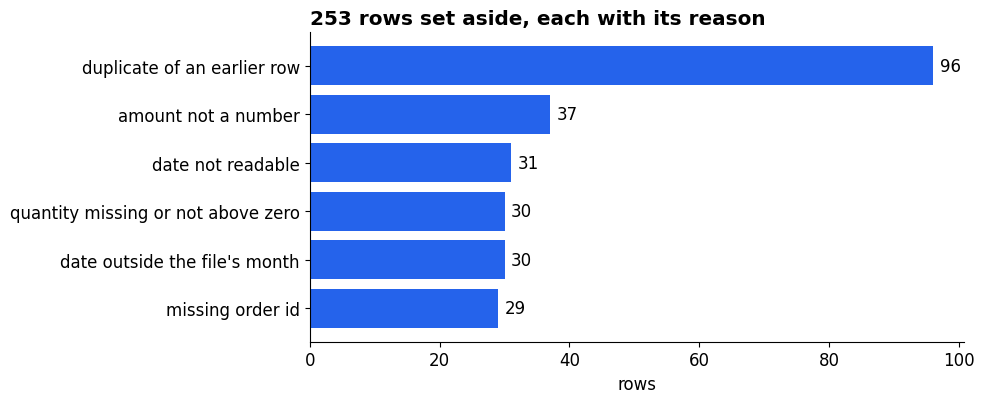

In [8]:
plt.rcParams.update({"font.size": 12, "axes.spines.top": False, "axes.spines.right": False})

counts = aside["reason"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(counts.index, counts.values, color=BLUE)
for y, v in enumerate(counts.values):
    ax.text(v + 1, y, str(v), va="center")
ax.set_title(f"{len(aside)} rows set aside, each with its reason", loc="left", fontweight="bold")
ax.set_xlabel("rows")
fig.tight_layout()
fig.savefig(DOCS / "errors-by-reason.png", dpi=150)
plt.show()

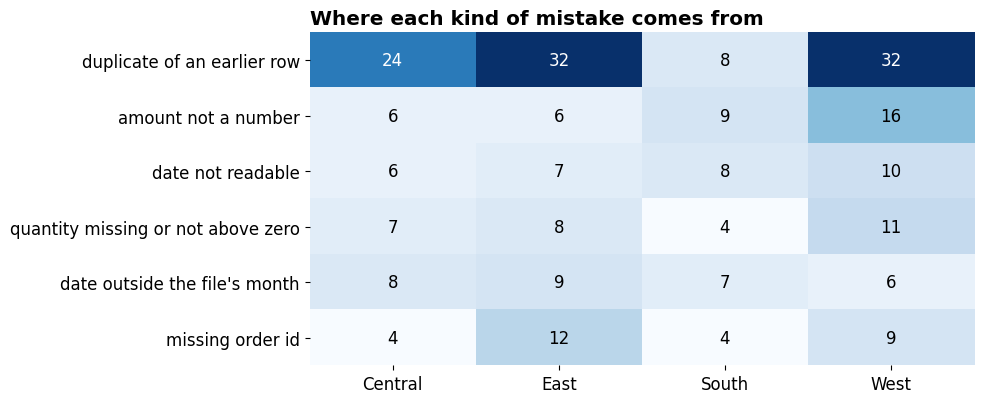

In [9]:
grid = pd.crosstab(aside["reason"], aside["branch"]).loc[counts.index[::-1]]
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.imshow(grid.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(grid.columns)), grid.columns)
ax.set_yticks(range(len(grid.index)), grid.index)
for (y, x), v in pd.DataFrame(grid.values).stack().items():
    ax.text(x, y, str(v), ha="center", va="center", color="white" if v > grid.values.max() / 2 else "black")
ax.set_title("Where each kind of mistake comes from", loc="left", fontweight="bold")
ax.spines[:].set_visible(False)
fig.tight_layout()
fig.savefig(DOCS / "errors-by-branch.png", dpi=150)
plt.show()

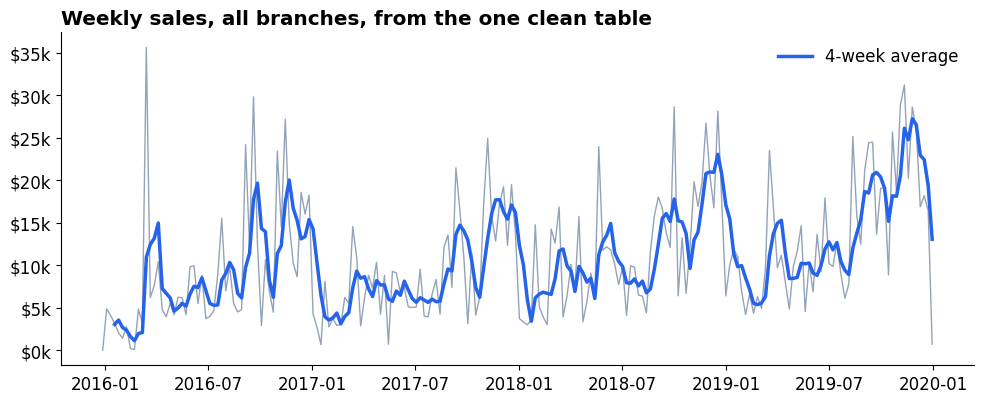

In [10]:
weekly = sales.groupby(sales["order_date"].dt.to_period("W-SUN").dt.start_time)["sales"].sum()
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(weekly.index, weekly.values, color=GREY, linewidth=1)
ax.plot(weekly.index, weekly.rolling(4).mean().values, color=BLUE, linewidth=2.5, label="4-week average")
ax.set_title("Weekly sales, all branches, from the one clean table", loc="left", fontweight="bold")
ax.yaxis.set_major_formatter(lambda v, _: f"${v / 1000:.0f}k")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(DOCS / "weekly-sales.png", dpi=150)
plt.show()

## The numbers for the portfolio card

In [11]:
print(f"title:  {len(files)} branch Excel files merged into one weekly report in one click")
print(f"result: {rows_read:,} rows across {len(files)} branch files: {len(aside)} errors caught, "
      f"report rebuilt in {round(seconds)} seconds")

title:  192 branch Excel files merged into one weekly report in one click
result: 10,089 rows across 192 branch files: 253 errors caught, report rebuilt in 44 seconds
